# Growth curves, 2026-09-30

OD600 of DH5α with and without pUC19-gfp in LB + ampicillin (100 µg/mL), 37 °C, read every 30 min. Doubling time from the exponential-phase growth rate $\mu$: $t_d = \ln 2 / \mu$.

*The readings here are simulated for Prem's example vault.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
hours = np.arange(0, 12.5, 0.5)

def logistic(t, k, r, t0):
    return k / (1 + np.exp(-r * (t - t0)))

od = pd.DataFrame({
    'hours': hours,
    'DH5α': logistic(hours, 2.1, 1.05, 5.0) + rng.normal(0, 0.02, hours.size) + 0.05,
    'DH5α + pUC19-gfp': logistic(hours, 1.9, 0.88, 6.0) + rng.normal(0, 0.02, hours.size) + 0.05,
}).round(3)

In [2]:
od.iloc[::4]

,hours,DH5α,DH5α + pUC19-gfp
0,0.0,0.061,0.056
4,2.0,0.127,0.107
8,4.0,0.585,0.313
12,6.0,1.608,1.018
16,8.0,2.037,1.672
20,10.0,2.102,1.864
24,12.0,2.152,1.980


In [3]:
def doubling_time(series):
    exp = series[(series > 0.1) & (series < 0.6)]
    mu = np.polyfit(od.loc[exp.index, 'hours'], np.log(exp), 1)[0]
    return np.log(2) / mu * 60

for strain in ['DH5α', 'DH5α + pUC19-gfp']:
    print(f'{strain}: doubling time {doubling_time(od[strain]):.0f} min')

DH5α: doubling time 52 min
DH5α + pUC19-gfp: doubling time 66 min


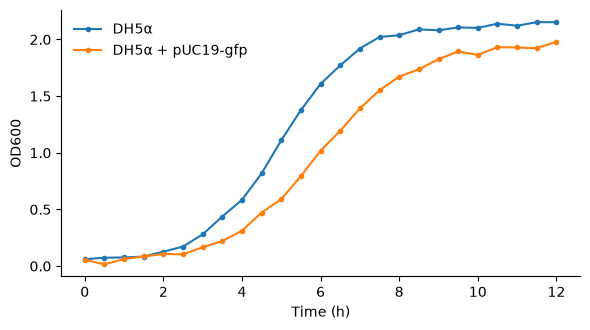

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.4))
for strain in ['DH5α', 'DH5α + pUC19-gfp']:
    ax.plot(od['hours'], od[strain], marker='o', ms=3, label=strain)
ax.set_xlabel('Time (h)')
ax.set_ylabel('OD600')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

## Conclusion

The plasmid-carrying strain grows about a quarter slower (66 vs 52 min doubling time), as expected from ampicillin selection and GFP expression. Use cultures at OD600 0.4–0.6 (around 4.5 h) for competent cells.